In [57]:
from astropy.table import Table
from astropy.io import fits
from collections import Counter
from src.plt_params import set_rc_params

import matplotlib.pyplot as plt
import numpy as np

catalog_dir = "/home/alab_student/Tim/Projects/MeV_Blazars/Data/"
outdir = '/home/alab_student/Tim/Projects/MeV_Blazars/Outputs'

In [58]:
set_rc_params(fontsize=20)

# Forecasting for Cross-Matched Sources

In [59]:
# Import flux estimates from SED modeling of cross matched sources.

MeV_Blazar_Catalog_SED_Fits = Table.read(catalog_dir + "MeV_Blazar_Catalog_v2_SED_Fits.fits")

MeV_Estimated_Fluxes = [list(x) for x in MeV_Blazar_Catalog_SED_Fits['MeV_Flux_Estimates'].tolist()]
Blazar_Classes = MeV_Blazar_Catalog_SED_Fits['Fermi_Type'].tolist()
Flux_Ratios = MeV_Blazar_Catalog_SED_Fits['Flux_Ratio'].tolist()
MeV_Flux_Estimates_By_Band = list(zip(*MeV_Estimated_Fluxes))

FSRQ_Flux_Estimates = list(zip(*[MeV_Estimated_Fluxes[i] for i in range(len(MeV_Estimated_Fluxes)) if Blazar_Classes[i].upper() == 'FSRQ']))
BLL_Flux_Estimates = list(zip(*[MeV_Estimated_Fluxes[i] for i in range(len(MeV_Estimated_Fluxes)) if Blazar_Classes[i].upper() == 'BLL']))
Flaring_Flux_Estimates = [[x*y for x,y in list(zip(Flux_Ratios, MeV_Flux_Estimates_By_Band[i]))] for i in range(len(MeV_Flux_Estimates_By_Band))]

In [60]:
# Sensitivity limit requirements for source detection.

print(f"Sensitivity limit required to detect one blazar at one energy: {max(max(sublist) for sublist in MeV_Flux_Estimates_By_Band):.1e} erg/cm^2/s") 
print(f"Sensitivity limit required to detect all blazars at all energies: {min(min(sublist) for sublist in MeV_Flux_Estimates_By_Band):.1e} erg/cm^2/s")
print("")
print(f"Sensitivity limit required to detect one FSRQ at one energy: {max(max(sublist) for sublist in FSRQ_Flux_Estimates):.1e} erg/cm^2/s") 
print(f"Sensitivity limit required to detect all FSRQs at all energies: {min(min(sublist) for sublist in FSRQ_Flux_Estimates):.1e} erg/cm^2/s")
print("")
print(f"Sensitivity limit required to detect one BL Lac at one energy: {max(max(sublist) for sublist in BLL_Flux_Estimates):.1e} erg/cm^2/s") 
print(f"Sensitivity limit required to detect all BL Lacs at all energies: {min(min(sublist) for sublist in BLL_Flux_Estimates):.1e} erg/cm^2/s")

Sensitivity limit required to detect one blazar at one energy: 3.9e-10 erg/cm^2/s
Sensitivity limit required to detect all blazars at all energies: 1.6e-14 erg/cm^2/s

Sensitivity limit required to detect one FSRQ at one energy: 3.9e-10 erg/cm^2/s
Sensitivity limit required to detect all FSRQs at all energies: 4.4e-13 erg/cm^2/s

Sensitivity limit required to detect one BL Lac at one energy: 8.7e-11 erg/cm^2/s
Sensitivity limit required to detect all BL Lacs at all energies: 1.6e-14 erg/cm^2/s


In [61]:
# Source counts for different orders of magnitude sensitivity limits.

N_10_10_all = [len([x for x in MeV_Flux_Estimates_By_Band[i] if x >= 1e-10]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_10_flaring = [len([x for x in Flaring_Flux_Estimates[i] if x >= 1e-10]) for i in range(len(Flaring_Flux_Estimates))]
N_10_10_FSRQ = [len([x for x in FSRQ_Flux_Estimates[i] if x >= 1e-10]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_10_BLL = [len([x for x in BLL_Flux_Estimates[i] if x >= 1e-10]) for i in range(len(MeV_Flux_Estimates_By_Band))]

N_10_11_all = [len([x for x in MeV_Flux_Estimates_By_Band[i] if x >= 1e-11]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_11_flaring = [len([x for x in Flaring_Flux_Estimates[i]if x >= 1e-11]) for i in range(len(Flaring_Flux_Estimates))]
N_10_11_FSRQ = [len([x for x in FSRQ_Flux_Estimates[i] if x >= 1e-11]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_11_BLL = [len([x for x in BLL_Flux_Estimates[i] if x >= 1e-11]) for i in range(len(MeV_Flux_Estimates_By_Band))]

N_10_12_all = [len([x for x in MeV_Flux_Estimates_By_Band[i] if x >= 1e-12]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_12_FSRQ = [len([x for x in FSRQ_Flux_Estimates[i] if x >= 1e-12]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_12_BLL = [len([x for x in BLL_Flux_Estimates[i] if x >= 1e-12]) for i in range(len(MeV_Flux_Estimates_By_Band))]

print(f"N(>10e-10), all: {N_10_10_all}")
print(f"N(>10e-10), flaring: {N_10_10_flaring}")
print(f"N(>10e-10), FSRQ: {N_10_10_FSRQ}")
print(f"N(>10e-10), BLL: {N_10_10_BLL}")
print("")
print(f"N(>10e-11), all: {N_10_11_all}")
print(f"N(>10e-11), flaring: {N_10_11_flaring}")
print(f"N(>10e-11), FSRQ: {N_10_11_FSRQ}")
print(f"N(>10e-11), BLL: {N_10_11_BLL}")
print("")
print(f"N(>10e-12), all: {N_10_12_all}")
print(f"N(>10e-12), FSRQ: {N_10_12_FSRQ}")
print(f"N(>10e-12), BLL: {N_10_12_BLL}")

N(>10e-10), all: [2, 3, 3, 5, 6, 6, 6, 5, 5]
N(>10e-10), flaring: [8, 12, 12, 17, 18, 16, 14, 13, 12]
N(>10e-10), FSRQ: [2, 3, 3, 5, 6, 6, 6, 5, 5]
N(>10e-10), BLL: [0, 0, 0, 0, 0, 0, 0, 0, 0]

N(>10e-11), all: [42, 52, 55, 58, 60, 58, 54, 49, 47]
N(>10e-11), flaring: [74, 74, 74, 77, 74, 74, 72, 70, 65]
N(>10e-11), FSRQ: [36, 44, 46, 48, 48, 47, 44, 39, 37]
N(>10e-11), BLL: [4, 6, 7, 7, 9, 9, 9, 9, 9]

N(>10e-12), all: [107, 104, 99, 94, 89, 90, 90, 88, 87]
N(>10e-12), FSRQ: [60, 61, 61, 61, 61, 61, 61, 60, 59]
N(>10e-12), BLL: [36, 32, 28, 23, 20, 21, 21, 20, 20]


In [62]:
# Total number of individual sources detectable per instrument.

Names = MeV_Blazar_Catalog_SED_Fits['Fermi_Counterpart_Name'].tolist()

N_10_10_all_names = [[x[0] for x in list(zip(Names, MeV_Flux_Estimates_By_Band[i])) if x[1] >= 1e-10] for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_10_flaring_names = [[x[0] for x in list(zip(Names, Flaring_Flux_Estimates[i])) if x[1] >= 1e-10] for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_10_FSRQ_names = [[x[0] for x in list(zip(Names, FSRQ_Flux_Estimates[i])) if x[1] >= 1e-10] for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_10_BLL_names = [[x[0] for x in list(zip(Names, BLL_Flux_Estimates[i])) if x[1] >= 1e-10] for i in range(len(MeV_Flux_Estimates_By_Band))]

N_10_11_all_names = [[x[0] for x in list(zip(Names, MeV_Flux_Estimates_By_Band[i])) if x[1] >= 1e-11] for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_11_flaring_names = [[x[0] for x in list(zip(Names, Flaring_Flux_Estimates[i])) if x[1] >= 1e-11] for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_11_FSRQ_names = [[x[0] for x in list(zip(Names, FSRQ_Flux_Estimates[i])) if x[1] >= 1e-11] for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_11_BLL_names = [[x[0] for x in list(zip(Names, BLL_Flux_Estimates[i])) if x[1] >= 1e-11] for i in range(len(MeV_Flux_Estimates_By_Band))]

N_10_12_all_names = [[x[0] for x in list(zip(Names, MeV_Flux_Estimates_By_Band[i])) if x[1] >= 1e-12] for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_12_flaring_names = [[x[0] for x in list(zip(Names, Flaring_Flux_Estimates[i])) if x[1] >= 1e-12] for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_12_FSRQ_names = [[x[0] for x in list(zip(Names, FSRQ_Flux_Estimates[i])) if x[1] >= 1e-12] for i in range(len(MeV_Flux_Estimates_By_Band))]
N_10_12_BLL_names = [[x[0] for x in list(zip(Names, BLL_Flux_Estimates[i])) if x[1] >= 1e-12] for i in range(len(MeV_Flux_Estimates_By_Band))]


print(f"N(>10e-10), all: {len({item for sublist in N_10_10_all_names for item in sublist})}", {item for sublist in N_10_10_all_names for item in sublist})
print(f"N(>10e-10), flaring: {len({item for sublist in N_10_10_flaring_names for item in sublist})}", {item for sublist in N_10_10_flaring_names for item in sublist})
print(f"N(>10e-10), FSRQ: {len({item for sublist in N_10_10_FSRQ_names for item in sublist})}")
print(f"N(>10e-10), BLL: {len({item for sublist in N_10_10_BLL_names for item in sublist})}")
print("")
print(f"N(>10e-11), all: {len({item for sublist in N_10_11_all_names for item in sublist})}")
print(f"N(>10e-11), flaring: {len({item for sublist in N_10_11_flaring_names for item in sublist})}")
print(f"N(>10e-11), FSRQ: {len({item for sublist in N_10_11_FSRQ_names for item in sublist})}")
print(f"N(>10e-11), BLL: {len({item for sublist in N_10_11_BLL_names for item in sublist})}")
print("")
print(f"N(>10e-12), all: {len({item for sublist in N_10_12_all_names for item in sublist})}")
print(f"N(>10e-12), flaring: {len({item for sublist in N_10_12_flaring_names for item in sublist})}")
print(f"N(>10e-12), FSRQ: {len({item for sublist in N_10_12_FSRQ_names for item in sublist})}")
print(f"N(>10e-12), BLL: {len({item for sublist in N_10_12_BLL_names for item in sublist})}")

N(>10e-10), all: 7 {'3C 273', '4C +71.07', '3C 454.3', 'CTA 102', 'PKS 1830-211', 'PKS 1510-089', '3C 279'}
N(>10e-10), flaring: 19 {'4C +21.35', 'PKS 0402-362', '2MASS J16561677-3302127', 'NRAO 676', '3C 273', '3C 454.3', 'PKS 1830-211', '4C +38.41', 'PMN J0641-0320', '4C +71.07', 'PKS 2149-306', 'CTA 102', 'PKS 1510-089', 'BL Lac', '3C 279', 'PKS 0537-286', 'B2 2023+33', 'NRAO 150', 'PKS 1127-14'}
N(>10e-10), FSRQ: 7
N(>10e-10), BLL: 0

N(>10e-11), all: 63
N(>10e-11), flaring: 80
N(>10e-11), FSRQ: 50
N(>10e-11), BLL: 10

N(>10e-12), all: 109
N(>10e-12), flaring: 114
N(>10e-12), FSRQ: 61
N(>10e-12), BLL: 37


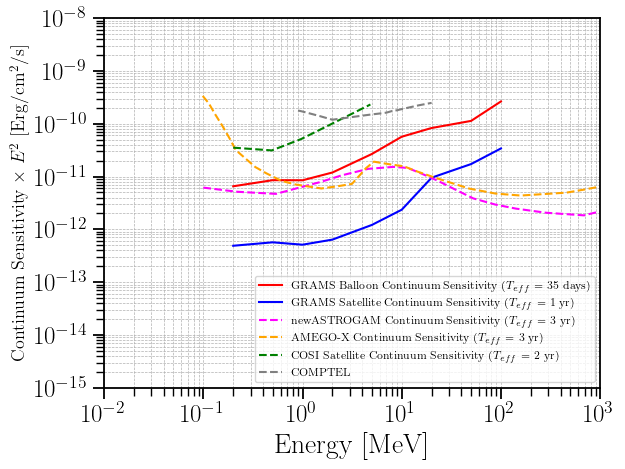

In [63]:
# Import Sensitivity Information for GRAMS Balloon, GRAMS Satellite, AMEGO-X, newASTROGAM, and COSI.

# GRAMS Balloon and Satellite: https://arxiv.org/pdf/1901.03430 (Figure 7.)
# AMEGO-X: https://arxiv.org/pdf/2208.04990 (Figure 3.)
# newASTROGAM: https://arxiv.org/pdf/2507.08133 (Figure 1.)
# COSI: https://arxiv.org/pdf/2308.12362 (Right Panel, Figure 2.)

Sensitivity_Curves_Table = Table.read(catalog_dir + 'Sensitivity_Curves_Data.csv')

GRAMS_Balloon_Energy = Sensitivity_Curves_Table['_GRAMS_Balloon_x'].tolist()[:9]
GRAMS_Balloon_Sensitivity = Sensitivity_Curves_Table['_GRAMS_Balloon_y'].tolist()[:9]

GRAMS_Satellite_Energy = Sensitivity_Curves_Table['_GRAMS_Satellite_x'].tolist()[:9]
GRAMS_Satellite_Sensitivity = Sensitivity_Curves_Table['_GRAMS_Satellite_y'].tolist()[:9]

newASTROGAM_energy_full = Sensitivity_Curves_Table['_newASTROGAM_x'].tolist()
newASTROGAM_sensitivity_full = Sensitivity_Curves_Table['_newASTROGAM_y'].tolist()

AMEGO_X_energy_full = Sensitivity_Curves_Table['_AMEGO_X_x'].tolist()
AMEGO_X_sensitivity_full = Sensitivity_Curves_Table['_AMEGO_X_y'].tolist()

COSI_Satellite_energy = Sensitivity_Curves_Table['_COSI_Satellite_x'].tolist()
COSI_Satellite_sensitivity = Sensitivity_Curves_Table['_COSI_Satellite_y'].tolist()

COMPTEL_energy = Sensitivity_Curves_Table['COMPTEL_x'].tolist()
COMPTEL_sensitivity = Sensitivity_Curves_Table['COMPTEL_y'].tolist()

plt.plot(GRAMS_Balloon_Energy, GRAMS_Balloon_Sensitivity, color='red', label=r'GRAMS Balloon Continuum Sensitivity ($T_{eff}$ = 35 days)', markersize=3)
plt.plot(GRAMS_Satellite_Energy, GRAMS_Satellite_Sensitivity, color='blue', label=r'GRAMS Satellite Continuum Sensitivity ($T_{eff}$ = 1 yr)', markersize=3)
plt.plot(newASTROGAM_energy_full, newASTROGAM_sensitivity_full, color='magenta',label=r'newASTROGAM Continuum Sensitivity ($T_{eff}$ = 3 yr)',markersize=3,linestyle='--')
plt.plot(AMEGO_X_energy_full, AMEGO_X_sensitivity_full, color='orange',label=r'AMEGO-X Continuum Sensitivity ($T_{eff}$ = 3 yr)',markersize=3,linestyle='--')
plt.plot(COSI_Satellite_energy, COSI_Satellite_sensitivity, color='green',label=r'COSI Satellite Continuum Sensitivity ($T_{eff}$ = 2 yr)',markersize=3,linestyle='--')
plt.plot(COMPTEL_energy, COMPTEL_sensitivity, color = 'grey',label=r'COMPTEL',linestyle='--')

plt.xlabel(r'Energy [MeV]')
plt.ylabel(r'Continuum Sensitivity $\times$ $E^{2}$ $\mathrm{[Erg/cm^{2}/s]}$', fontsize=13)
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-2,1e3)
plt.ylim(1e-15,1e-8)
plt.legend(loc = 'lower right', fontsize=8)
plt.grid(which='both', linestyle='--', linewidth=0.5)


In [64]:
# Sensitivity values at 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, and 100.0 MeV

Sensitivity_Data = Table.read(catalog_dir + 'Sensitivity_Data_Table.fits')

Select_Energy_Values = Sensitivity_Data['Energy'].tolist()
GRAMS_Balloon_Sensitivity = Sensitivity_Data['GRAMS_Balloon_Sensitivity'].tolist()
GRAMS_Satellite_Sensitivity = Sensitivity_Data['GRAMS_Satellite_Sensitivity'].tolist()
AMEGO_X_Sensitivity = Sensitivity_Data['AMEGO_X_Sensitivity'].tolist()
newASTROGAM_Sensitivity = Sensitivity_Data['newASTROGAM_Sensitivity'].tolist()
COSI_Sensitivity = Sensitivity_Data['COSI_Sensitivity'].tolist()

In [65]:
# Compute counts for each instrument

N_GRAMS_Balloon = [sum([x >= GRAMS_Balloon_Sensitivity[i] for x in MeV_Flux_Estimates_By_Band[i]]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_GRAMS_Satellite = [sum([x >= GRAMS_Satellite_Sensitivity[i] for x in MeV_Flux_Estimates_By_Band[i]]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_AMEGO_X = [sum([x >= AMEGO_X_Sensitivity[i] for x in MeV_Flux_Estimates_By_Band[i]]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_newASTROGAM = [sum([x >= newASTROGAM_Sensitivity[i] for x in MeV_Flux_Estimates_By_Band[i]]) for i in range(len(MeV_Flux_Estimates_By_Band))]
N_COSI = [sum([x >= COSI_Sensitivity[i] for x in MeV_Flux_Estimates_By_Band[i]]) for i in range(len(MeV_Flux_Estimates_By_Band))]

N_S_Intruments_Table = Table([Select_Energy_Values, GRAMS_Balloon_Sensitivity, N_GRAMS_Balloon, GRAMS_Satellite_Sensitivity, N_GRAMS_Satellite, newASTROGAM_Sensitivity, N_newASTROGAM, AMEGO_X_Sensitivity, N_AMEGO_X, COSI_Sensitivity, N_COSI], names=['Energy', 'S_GRAMS_Balloon', 'N_GRAMS_Balloon', 'S_GRAMS_Satellite', 'N_GRAMS_Satellite', 'S_newASTROGAM', 'N_newASTROGAM', 'S_AMEGO_X', 'N_AMEGO_X', 'S_COSI', 'N_COSI'])
N_S_Intruments_Table.pprint_all()

Energy S_GRAMS_Balloon N_GRAMS_Balloon S_GRAMS_Satellite N_GRAMS_Satellite S_newASTROGAM N_newASTROGAM S_AMEGO_X N_AMEGO_X  S_COSI  N_COSI
------ --------------- --------------- ----------------- ----------------- ------------- ------------- --------- --------- -------- ------
   0.2        6.53e-12              60          4.88e-13               113      5.26e-12            69  3.61e-11         6 3.52e-11      6
   0.5        8.52e-12              55          5.67e-13               109      4.69e-12            73  9.52e-12        53 3.12e-11     10
   1.0        8.48e-12              61          5.11e-13               108      6.37e-12            67  6.65e-12        67 5.13e-11      8
   2.0        1.19e-11              51          6.38e-13               102      9.44e-12            59  6.28e-12        69  9.8e-11      5
   5.0        2.67e-11              27          1.21e-12                89      1.43e-11            46  1.88e-11        39 2.31e-10      1
  10.0        5.67e-11     

In [66]:
# Individual source detectability by each instrument

GRAMS_Balloon_Detectable_Energies = []
GRAMS_Satellite_Detectable_Energies = []
newASTROGAM_Detectable_Energies = []
AMEGO_X_Detectable_Energies = []

for i in range(len(Names)):
    GRAMS_Balloon_Detectable_Energies.append([Select_Energy_Values[x] for x in range(len(Select_Energy_Values)) if MeV_Estimated_Fluxes[i][x] >= GRAMS_Balloon_Sensitivity[x]])
    GRAMS_Satellite_Detectable_Energies.append([Select_Energy_Values[x] for x in range(len(Select_Energy_Values)) if MeV_Estimated_Fluxes[i][x] >= GRAMS_Satellite_Sensitivity[x]])
    newASTROGAM_Detectable_Energies.append([Select_Energy_Values[x] for x in range(len(Select_Energy_Values)) if MeV_Estimated_Fluxes[i][x] >= newASTROGAM_Sensitivity[x]])
    AMEGO_X_Detectable_Energies.append([Select_Energy_Values[x] for x in range(len(Select_Energy_Values)) if MeV_Estimated_Fluxes[i][x] >= AMEGO_X_Sensitivity[x]])
    
Source_Detectability_Table = Table([Names, GRAMS_Balloon_Detectable_Energies, GRAMS_Satellite_Detectable_Energies, newASTROGAM_Detectable_Energies, AMEGO_X_Detectable_Energies], names=['Name', 'GRAMS_Balloon_Detectable_Energies', 'GRAMS_Satellite_Detectable_Energies', 'newASTROGAM_Detectable_Energies', 'AMEGO_X_Detectable_Energies'])

print(len(Names) - len([x for x in GRAMS_Balloon_Detectable_Energies if x == []]))
print(len(Names) - len([x for x in GRAMS_Satellite_Detectable_Energies if x == []]))
print(len(Names) - len([x for x in newASTROGAM_Detectable_Energies if x == []]))
print(len(Names) - len([x for x in AMEGO_X_Detectable_Energies if x == []]))


64
113
79
73


In [67]:
# Determine brightest blazars in MeV.

Brightest_Blazars = [[] for _ in range(18)]
Blazar_Names = MeV_Blazar_Catalog_SED_Fits['Fermi_Counterpart_Name'].tolist()

Names_brightest_instances = []

for i in range(len(MeV_Flux_Estimates_By_Band)):
    names_fluxes = list(zip(Blazar_Names, MeV_Flux_Estimates_By_Band[i]))
    top10 = [x for x in sorted(names_fluxes, key=lambda x: x[1], reverse=True)][:11]
    for x in range(len(top10)):
        Brightest_Blazars[2*i].append(top10[x][0])
        Brightest_Blazars[2*i+1].append(top10[x][1])
        Names_brightest_instances.append(top10[x][0])

    
print(Counter(Names_brightest_instances))

Brightest_Blazars_Table = Table(Brightest_Blazars, names=['Name_0_2', 'Flux_0_2', 'Name_0_5', 'Flux_0_5', 'Name_1_0', 'Flux_1_0', 'Name_2_0', 'Flux_2_0', 'Name_5_0', 'Flux_5_0', 'Name_10_0', 'Flux_10_0', 'Name_20_0', 'Flux_20_0', 'Name_50_0', 'Flux_50_0', 'Name_100_0', 'Flux_100_0'])
Brightest_Blazars_Table.pprint_all()

Counter({'3C 273': 9, '3C 454.3': 9, 'PKS 1830-211': 9, 'PKS 1510-089': 9, '3C 279': 9, 'CTA 102': 9, '4C +71.07': 8, 'BL Lac': 8, '4C +21.35': 7, 'PKS 2149-306': 6, 'PKS 0402-362': 5, '2MASS J16561677-3302127': 3, '4C +38.41': 3, 'S5 0212+73': 2, 'NRAO 140': 1, 'NRAO 150': 1, 'MG2 J201534+3710': 1})
        Name_0_2               Flux_0_2                Name_0_5               Flux_0_5                Name_1_0               Flux_1_0          Name_2_0          Flux_2_0          Name_5_0          Flux_5_0         Name_10_0         Flux_10_0         Name_20_0         Flux_20_0         Name_50_0         Flux_50_0           Name_100_0          Flux_100_0      
----------------------- ---------------------- ----------------------- ---------------------- ----------------------- ---------------------- ------------ ---------------------- ------------ ---------------------- ------------ ---------------------- ------------ ---------------------- ------------ ---------------------- ----------------

In [68]:
# Save Cross-Match Detectability Table

primary_hdu = fits.PrimaryHDU()
N_S_Intruments_Table = fits.BinTableHDU(data=N_S_Intruments_Table, name='TABLE1')
Source_Detectability_Table = fits.BinTableHDU(data=Source_Detectability_Table, name='TABLE2')
Brightest_Blazars_Table = fits.BinTableHDU(data=Brightest_Blazars_Table, name='TABLE3')

Cross_Match_Forecast_Table = fits.HDUList([primary_hdu, N_S_Intruments_Table, Source_Detectability_Table])
Cross_Match_Forecast_Table.writeto(catalog_dir + 'MeV_Instruments_Matched_Blazar_Forecast.fits', overwrite=True)

# Forecasting from Luminosity Function Models

## N(>S) Forecasting

In [69]:
# Import N(>S) calculation results.

Monochromatic_Luminosity_Function_Table_New = Table.read(catalog_dir + 'N_S_LF_Output.fits')
#Monochromatic_Luminosity_Function_Table_New.pprint_all()

Monochromatic_sensitivity_list_new = Monochromatic_Luminosity_Function_Table_New['Sensitivity'].tolist()

Mono_Toda_LF_New = [Monochromatic_Luminosity_Function_Table_New.columns[i].tolist() for i in [1,2,3,4,5,6,7,8,9]]
Mono_Rajguru_LF_New = [Monochromatic_Luminosity_Function_Table_New.columns[i].tolist() for i in [10,11,12,13,14,15,16,17,18]]
Mono_Marcotulli_LF_New = [Monochromatic_Luminosity_Function_Table_New.columns[i].tolist() for i in [19,20,21,22,23,24,25,26,27]]
Mono_Ajello_LF_New = [Monochromatic_Luminosity_Function_Table_New.columns[i+9].tolist() for i in [28,29,30,31,32,33,34,35,36]]

In [70]:
# Determine N(>S) counts from LFs at different orders of magnitude sensitivity.

Toda_10_10_New = []
Toda_10_11_New = []
Toda_10_12_New = []
Toda_10_13_New = []
Rajguru_10_10_New = []
Rajguru_10_11_New = []
Rajguru_10_12_New = []
Rajguru_10_13_New = []
Ajello_10_10_New = []
Ajello_10_11_New = []
Ajello_10_12_New = []
Marcotulli_10_10_New = []
Marcotulli_10_11_New = []
Marcotulli_10_12_New = []

for i in range(len(Select_Energy_Values)):
    
    for x in range(len(Monochromatic_sensitivity_list_new)):
        if Monochromatic_sensitivity_list_new[x] == 1e-10:
            Toda_10_10_New.append(round(Mono_Toda_LF_New[i][x],0))
            Rajguru_10_10_New.append(round(Mono_Rajguru_LF_New[i][x],0))
            Ajello_10_10_New.append(round(Mono_Ajello_LF_New[i][x],0))
            Marcotulli_10_10_New.append(round(Mono_Marcotulli_LF_New[i][x],0))
        if Monochromatic_sensitivity_list_new[x] == 1e-11:
            Toda_10_11_New.append(round(Mono_Toda_LF_New[i][x],0))
            Rajguru_10_11_New.append(round(Mono_Rajguru_LF_New[i][x],0))
            Ajello_10_11_New.append(round(Mono_Ajello_LF_New[i][x],0))
            Marcotulli_10_11_New.append(round(Mono_Marcotulli_LF_New[i][x],0))
        if Monochromatic_sensitivity_list_new[x] == 1e-12:
            Toda_10_12_New.append(round(Mono_Toda_LF_New[i][x],0))
            Rajguru_10_12_New.append(round(Mono_Rajguru_LF_New[i][x],0))
            Ajello_10_12_New.append(round(Mono_Ajello_LF_New[i][x],0))
            Marcotulli_10_12_New.append(round(Mono_Marcotulli_LF_New[i][x],0))
        if Monochromatic_sensitivity_list_new[x] == 1e-13:
            Toda_10_13_New.append(round(Mono_Toda_LF_New[i][x],0))
            Rajguru_10_13_New.append(round(Mono_Rajguru_LF_New[i][x],0))
            #Ajello_10_13_New.append(round(Mono_Ajello_LF_New[i][x],0))
            #Marcotulli_10_13_New.append(round(Mono_Marcotulli_LF_New[i][x],0))
            
print("Counts for Toda et al 2020")
print(f"N(>10e-11) {min(Toda_10_11_New), max(Toda_10_11_New)}")
print(f"N(>10e-12) {min(Toda_10_12_New), max(Toda_10_12_New)}")
print(f"N(>10e-13) {min(Toda_10_13_New), max(Toda_10_13_New)}")
print(" ")
print("Counts for Rajguru et al 2025")
print(f"N(>10e-11) {min(Rajguru_10_11_New), max(Rajguru_10_11_New)}")
print(f"N(>10e-12) {min(Rajguru_10_12_New), max(Rajguru_10_12_New)}")
print(f"N(>10e-13) {min(Rajguru_10_13_New), max(Rajguru_10_13_New)}")
print(" ")
print("Counts for Ajello et al 2013")
print(f"N(>10e-11) {min(Ajello_10_11_New), max(Ajello_10_11_New)}")
print(f"N(>10e-12) {min(Ajello_10_12_New), max(Ajello_10_12_New)}")
print(" ")
print("Counts for Marcotulli et al 2022")
print(f"N(>10e-11) {min(Marcotulli_10_11_New), max(Marcotulli_10_11_New)}")
print(f"N(>10e-12) {min(Marcotulli_10_12_New), max(Marcotulli_10_12_New)}")

Counts for Toda et al 2020
N(>10e-11) (32.0, 49.0)
N(>10e-12) (225.0, 264.0)
N(>10e-13) (1091.0, 1250.0)
 
Counts for Rajguru et al 2025
N(>10e-11) (289.0, 416.0)
N(>10e-12) (868.0, 938.0)
N(>10e-13) (1274.0, 1313.0)
 
Counts for Ajello et al 2013
N(>10e-11) (347.0, 360.0)
N(>10e-12) (1941.0, 2120.0)
 
Counts for Marcotulli et al 2022
N(>10e-11) (48.0, 79.0)
N(>10e-12) (1152.0, 2061.0)


In [71]:
# Print total expected cumulative counts for MeV gamma-ray instruments.

Sensitivities = [GRAMS_Balloon_Sensitivity, GRAMS_Satellite_Sensitivity, newASTROGAM_Sensitivity, AMEGO_X_Sensitivity]

GRAMS_Balloon_Rajguru = []
GRAMS_Balloon_Marcotulli = []
GRAMS_Balloon_Ajello = []
GRAMS_Balloon_Toda = []

GRAMS_Satellite_Rajguru = []
GRAMS_Satellite_Marcotulli = []
GRAMS_Satellite_Ajello = []
GRAMS_Satellite_Toda = []

newASTROGAM_Rajguru = []
newASTROGAM_Marcotulli = []
newASTROGAM_Ajello = []
newASTROGAM_Toda = []

AMEGO_X_Rajguru = []
AMEGO_X_Marcotulli = []
AMEGO_X_Ajello = []
AMEGO_X_Toda = []

for x in range(len(Sensitivities)):
    for i in range(len(Sensitivities[x])):
        Index = min(enumerate(Monochromatic_sensitivity_list_new), key=lambda s: abs(Sensitivities[x][i] - s[1]))[0]

        if x == 0:
            GRAMS_Balloon_Rajguru.append(round(Mono_Rajguru_LF_New[i][Index], 0))
            GRAMS_Balloon_Marcotulli.append(round(Mono_Marcotulli_LF_New[i][Index],0))
            GRAMS_Balloon_Ajello.append(round(Mono_Ajello_LF_New[i][Index],0))
            GRAMS_Balloon_Toda.append(round(Mono_Toda_LF_New[i][Index],0))
        if x == 1:
            GRAMS_Satellite_Rajguru.append(round(Mono_Rajguru_LF_New[i][Index],0))
            GRAMS_Satellite_Marcotulli.append(round(Mono_Marcotulli_LF_New[i][Index],0))
            GRAMS_Satellite_Ajello.append(round(Mono_Ajello_LF_New[i][Index],0))
            GRAMS_Satellite_Toda.append(round(Mono_Toda_LF_New[i][Index],0))
        if x == 2:
            newASTROGAM_Rajguru.append(round(Mono_Rajguru_LF_New[i][Index], 0))
            newASTROGAM_Marcotulli.append(round(Mono_Marcotulli_LF_New[i][Index],0))
            newASTROGAM_Ajello.append(round(Mono_Ajello_LF_New[i][Index],0))
            newASTROGAM_Toda.append(round(Mono_Toda_LF_New[i][Index],0))
        if x == 3:
            AMEGO_X_Rajguru.append(round(Mono_Rajguru_LF_New[i][Index],0))
            AMEGO_X_Marcotulli.append(round(Mono_Marcotulli_LF_New[i][Index],0))
            AMEGO_X_Ajello.append(round(Mono_Ajello_LF_New[i][Index],0))
            AMEGO_X_Toda.append(round(Mono_Toda_LF_New[i][Index],0))
            
COSI_Rajguru = []
COSI_Marcotulli = []
COSI_Ajello = []
COSI_Toda = []
            
for i in range(len(COSI_Sensitivity) - 4):
    Index = min(enumerate(Monochromatic_sensitivity_list_new), key=lambda s: abs(COSI_Sensitivity[i] - s[1]))[0]
    COSI_Rajguru.append(round(Mono_Rajguru_LF_New[i][Index], 0))
    COSI_Marcotulli.append(round(Mono_Marcotulli_LF_New[i][Index], 0))
    COSI_Ajello.append(round(Mono_Ajello_LF_New[i][Index], 0))
    COSI_Toda.append(round(Mono_Toda_LF_New[i][Index], 0))
            
print("GRAMS Balloon")     
print("Rajguru", max(GRAMS_Balloon_Rajguru), min(GRAMS_Balloon_Rajguru))
print("Marcotulli", max(GRAMS_Balloon_Marcotulli))
print("Ajello",max(GRAMS_Balloon_Ajello), min(GRAMS_Balloon_Ajello))
print("Toda",max(GRAMS_Balloon_Toda), min(GRAMS_Balloon_Toda))
print("")
print("GRAMS Satellite")     
print("Rajguru",max(GRAMS_Satellite_Rajguru), min(GRAMS_Satellite_Rajguru))
print("Marcotulli",max(GRAMS_Satellite_Marcotulli), min(GRAMS_Satellite_Marcotulli))
print("Ajello",max(GRAMS_Satellite_Ajello), min(GRAMS_Satellite_Ajello))
print("Toda",max(GRAMS_Satellite_Toda), min(GRAMS_Satellite_Toda))
print("")
print("newASTROGAM")     
print("Rajguru",max(newASTROGAM_Rajguru))
print("Marcotulli",max(newASTROGAM_Marcotulli))
print("Ajello",max(newASTROGAM_Ajello))
print("Toda",max(newASTROGAM_Toda))
print("")
print("AMEGO-X")     
print("Rajguru",max(AMEGO_X_Rajguru))
print("Marcotulli",max(AMEGO_X_Marcotulli))
print("Ajello",max(AMEGO_X_Ajello))
print("Toda",max(AMEGO_X_Toda))
print("")
print("COSI")
print("Rajguru",max(COSI_Rajguru))
print("Marcotulli",max(COSI_Marcotulli))
print("Ajello",max(COSI_Ajello))
print("Toda",max(COSI_Toda))

GRAMS Balloon
Rajguru 533.0 5.0
Marcotulli 157.0
Ajello 547.0 2.0
Toda 74.0 0.0

GRAMS Satellite
Rajguru 1067.0 91.0
Marcotulli 5671.0 10.0
Ajello 3036.0 89.0
Toda 422.0 7.0

newASTROGAM
Rajguru 664.0
Marcotulli 348.0
Ajello 1185.0
Toda 121.0

AMEGO-X
Rajguru 504.0
Marcotulli 144.0
Ajello 731.0
Toda 73.0

COSI
Rajguru 174.0
Marcotulli 16.0
Ajello 101.0
Toda 12.0


## N(>z) Forecasting

In [72]:
# Maximum redshifts for cross-matched blazar sub-populations.

SED_Selected_Model_Params = Table.read(catalog_dir + 'SED_Selected_Model_Params.fits')

Redshifts = SED_Selected_Model_Params['Redshift'].tolist()
Classes = SED_Selected_Model_Params['Class'].tolist()
Models = SED_Selected_Model_Params['Model'].tolist()

FSRQ_Redshifts = [float(Redshifts[x]) for x in range(len(Redshifts)) if Classes[x].upper() == 'FSRQ']
FSRQ_Redshifts.sort(reverse=True)

LP_BLL_Redshifts = [float(Redshifts[x]) for x in range(len(Redshifts)) if Classes[x].upper() == 'BLL' and Models[x] == 'LP']
LP_BLL_Redshifts.sort(reverse=True)

SBPL_BLL_Redshifts = [float(Redshifts[x]) for x in range(len(Redshifts)) if Classes[x].upper() == 'BLL' and Models[x] == 'SBPL']
SBPL_BLL_Redshifts.sort(reverse=True)

print(FSRQ_Redshifts[:5])
print(LP_BLL_Redshifts[:5])
print(SBPL_BLL_Redshifts[:5])


[3.104, 3.033, 2.9793, 2.752, 2.69]
[1.1100000143051147, 0.894, 0.68, 0.3, 0.219]
[0.3604, 0.36, 0.314, 0.272, 0.2645]


In [73]:
# Maximum redshifts based on LF estimates.

N_z_LF_data_results = Table.read(catalog_dir + 'N_z_LF_output.fits')
N_z_LF_redshifts = N_z_LF_data_results['Redshift'].tolist()
N_z_BLL_redshifts = N_z_LF_data_results['BLL_Redshift'].tolist()

Instrument_Names = ['GRAMS Balloon', 'GRAMS Satellite', 'newASTROGAM', 'AMEGO-X']
lit_labels = ['A13','T20', 'R25', 'M22']

z_at_count_1 = {(l_label, inst): [] for l_label in lit_labels for inst in Instrument_Names}
N_at_z_3 = {(l_label, inst): [] for l_label in lit_labels for inst in Instrument_Names}

for i in range(len(Select_Energy_Values)):
    N_z_LF_data_all = [[N_z_LF_data_results.columns[n].tolist() for n in [m+i+1 for m in [1, 10, 19, 28]]],
                       [N_z_LF_data_results.columns[n].tolist() for n in [m+i+1 for m in [37, 46, 55, 64]]],
                       [N_z_LF_data_results.columns[n].tolist() for n in [m+i+36+1 for m in [37, 46, 55, 64]]],
                       [N_z_LF_data_results.columns[n].tolist() for n in [m+i+1 for m in [109, 118, 127, 136]]]]
    
    for s in range(len(Sensitivities)):
        for l in range(len(lit_labels)):
            y_data = np.asarray(N_z_LF_data_all[l][s]).flatten()
            z_1_index, z_1_value = min(enumerate(y_data), key=lambda x: abs(1 - x[1]))
            if l != 0:   
                z_3_index, z_3_value = min(enumerate(N_z_LF_redshifts), key=lambda x: abs(3 - x[1]))
                N_3 = y_data[z_3_index]
                z_1_at_this_index = N_z_LF_redshifts[z_1_index]
            if l == 0:
                z_3_index, z_3_value = min(enumerate(N_z_BLL_redshifts), key=lambda x: abs(3 - x[1]))
                N_3 = y_data[z_3_index]
                z_1_at_this_index = N_z_BLL_redshifts[z_1_index]
            
            z_at_count_1[(lit_labels[l], Instrument_Names[s])].append(z_1_at_this_index)
            N_at_z_3[(lit_labels[l], Instrument_Names[s])].append(N_3)
            
for l in range(len(lit_labels)):           
    for s in range(len(Sensitivities)):
        if l != 3:
            print((lit_labels[l], Instrument_Names[s]), max(z_at_count_1[(lit_labels[l], Instrument_Names[s])]), min(z_at_count_1[(lit_labels[l], Instrument_Names[s])]))
            print((lit_labels[l], Instrument_Names[s]), max(N_at_z_3[(lit_labels[l], Instrument_Names[s])]), min(N_at_z_3[(lit_labels[l], Instrument_Names[s])]))
            print("")


('A13', 'GRAMS Balloon') 2.3636363636363638 0.7878787878787878
('A13', 'GRAMS Balloon') 0.07504804777095908 7.809796449829076e-07

('A13', 'GRAMS Satellite') 3.8181818181818183 1.6363636363636365
('A13', 'GRAMS Satellite') 11.164987853168888 0.00010876827490006332

('A13', 'newASTROGAM') 2.787878787878788 1.9393939393939394
('A13', 'newASTROGAM') 0.35067690350363945 0.0022380840958194062

('A13', 'AMEGO-X') 2.484848484848485 1.8181818181818183
('A13', 'AMEGO-X') 0.04498735481564217 0.0010115455882210697

('T20', 'GRAMS Balloon') 5.6565656565656575 0.0
('T20', 'GRAMS Balloon') 5.141370682717236 1.4523930376009916e-07

('T20', 'GRAMS Satellite') 6.545454545454546 0.6464646464646465
('T20', 'GRAMS Satellite') 11.683858922950455 0.002252392404817515

('T20', 'newASTROGAM') 5.818181818181818 2.0202020202020203
('T20', 'newASTROGAM') 5.805562305095812 0.2803755969551047

('T20', 'AMEGO-X') 5.090909090909092 1.6161616161616164
('T20', 'AMEGO-X') 3.9310992856024387 0.215579506371452

('R25', '